# CellLineSelector — Data Quality & Distribution EDA

This notebook is the **second pass** of EDA, building on [`holistic_overview.ipynb`](holistic_overview.ipynb), where we toured all 14 raw files and learned what each one represents biologically.

Here the focus shifts from *"what is this data?"* to *"is this data usable, and how should we treat it before modelling?"*. Concretely, for the files that matter most for modelling, we will:

1. **Visualise** key distributions and categorical breakdowns.
2. **Locate missing data** — which columns/cells are empty, and is the pattern random or systematic?
3. **Flag columns to drop** — mostly-empty columns that add little signal.
4. **Flag columns to impute** — partially-empty but biologically important columns.
5. **Summarise correlation** for the wide gene-level tables *without* attempting an unreadable 50,000 x 50,000 matrix.
6. **Summarise skewness & kurtosis** the same way — as distributions across genes, not per-gene tables.

## A note on scale

Several tables here have **thousands to tens of thousands of columns** (one row per cell line, one column per gene/protein/miRNA). A classic correlation heatmap or a per-column skew/kurtosis table only makes sense when the number of columns is small enough to read (roughly < 50). For the big gene-level tables we therefore:

- Compute correlation **only on a manageable subset** of the most informative genes (highest variance — i.e. genes that actually differ between cell lines, which is what makes them useful for distinguishing/selecting cell lines).
- Summarise skewness/kurtosis as a **histogram over all genes** ("how skewed is the typical gene's expression distribution?") rather than reporting it gene-by-gene.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

RAW = '../../data/raw'
GENE_EXPR = f'{RAW}/gene_expression'
GENE_PROP = f'{RAW}/gene_properties'
NOMEN = f'{RAW}/nomenclature'
NON_GENE_EXPR = f'{RAW}/non_gene_expression'

RNG = np.random.default_rng(42)  # fixed seed for any sampling below

---
# 1. Nomenclature — File 9: DepMap Sample Info

**Recap:** one row per cell line (~1,840), with clinical/biological metadata (cancer type, tissue, sex, age...). Because this table becomes the backbone of our master cell-line index, its missingness directly determines how much context we can attach to every other dataset.

In [2]:
sample_info = pd.read_csv(f'{NOMEN}/9_DepMap_sample_info.csv')
sample_info.shape

(1840, 29)

## 1.1 Missingness overview

A horizontal bar chart of the fraction of missing values per column, sorted descending, makes it immediately obvious which columns are essentially empty vs. which are nearly complete.

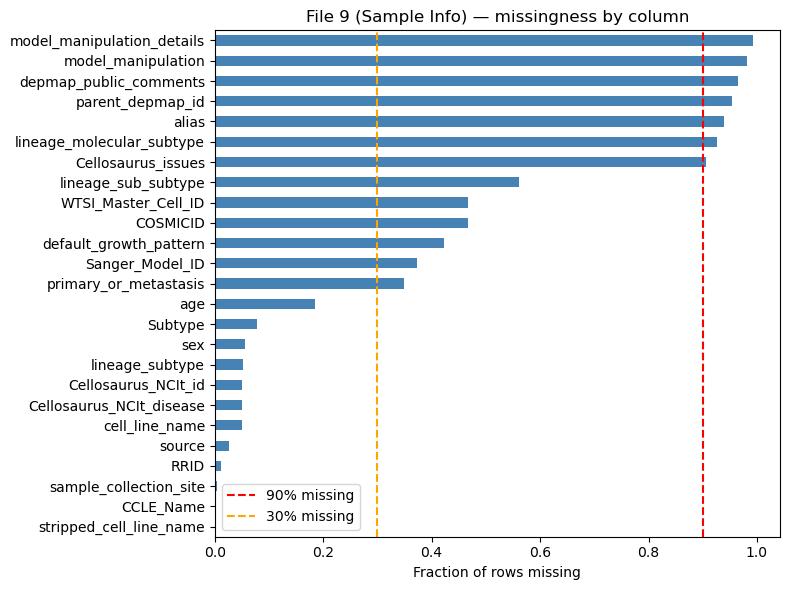

In [3]:
missing_frac = sample_info.isna().mean().sort_values(ascending=False)
missing_frac = missing_frac[missing_frac > 0]

fig, ax = plt.subplots(figsize=(8, 6))
missing_frac.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Fraction of rows missing')
ax.set_title('File 9 (Sample Info) — missingness by column')
ax.invert_yaxis()
ax.axvline(0.9, color='red', linestyle='--', label='90% missing')
ax.axvline(0.3, color='orange', linestyle='--', label='30% missing')
ax.legend()
plt.tight_layout()
plt.show()

### Reading this chart — and our column decisions

**Flag to drop (>90% missing, little modelling value):**
- `model_manipulation_details`, `model_manipulation` (~98-99% missing) — free-text notes only present for the rare genetically-engineered line.
- `depmap_public_comments` (~97%) — sparse free-text comments.
- `parent_depmap_id` (~95%) — only populated for derivative cell lines.
- `alias` (~94%) — most lines have no extra alias beyond their primary name (and Cellosaurus, File 7, covers aliases far more completely).
- `lineage_molecular_subtype` (~93%) and `Cellosaurus_issues` (~91%) — too sparse to be a reliable feature.

**Flag for imputation (partially missing, but biologically meaningful):**
- `lineage_sub_subtype` (~56%) and `primary_or_metastasis` (~35%) — useful tumour-context fields; missing likely means "not recorded" rather than "not applicable", so impute with an explicit `"Unknown"` category rather than dropping.
- `age` (~19%) and `Subtype` (~8%) — worth keeping; impute `age` with median (or `"Unknown"` bucket) and `Subtype` with `"Unknown"`.
- `COSMICID`, `Sanger_Model_ID`, `WTSI_Master_Cell_ID` (~37-47%) — these are *cross-reference IDs* to other databases (COSMIC, Sanger). Missingness here just means "this cell line isn't catalogued in that external database" — not something to impute numerically, but worth keeping as optional join keys.

**Keep as-is:** everything else (<8% missing), including the core identifiers (`DepMap_ID`, `cell_line_name`), `lineage`, and `primary_disease` — these are essentially complete and form the foundation of our master index.

## 1.2 Distribution of cell lines across cancer types and tissues

Understanding *how many candidate cell lines exist per cancer type* tells us where our shortlist-of-10 will have plenty of choice, and where it might be constrained to just a handful of options.

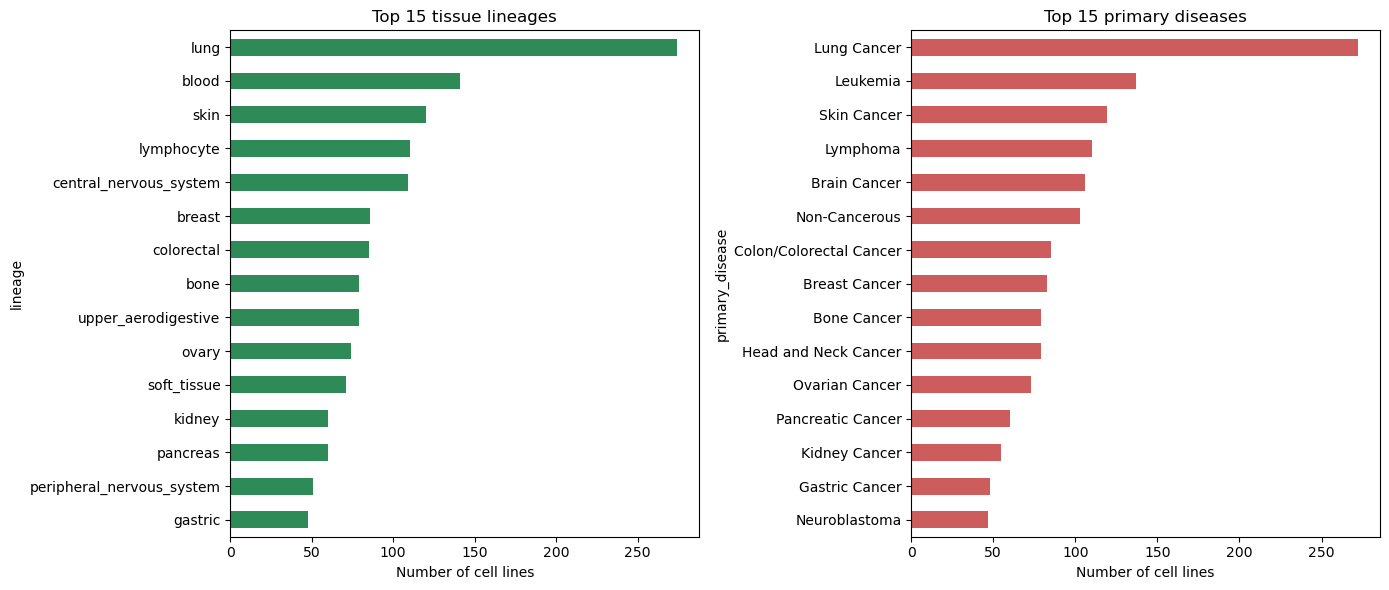

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sample_info['lineage'].value_counts().head(15).plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('Top 15 tissue lineages')
axes[0].set_xlabel('Number of cell lines')
axes[0].invert_yaxis()

sample_info['primary_disease'].value_counts().head(15).plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Top 15 primary diseases')
axes[1].set_xlabel('Number of cell lines')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

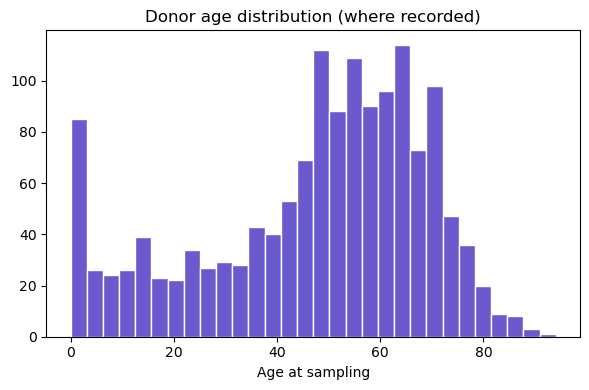

Skewness: -0.67
Kurtosis: -0.46


In [5]:
age = pd.to_numeric(sample_info['age'], errors='coerce').dropna()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(age, bins=30, color='slateblue', edgecolor='white')
ax.set_title('Donor age distribution (where recorded)')
ax.set_xlabel('Age at sampling')
plt.tight_layout()
plt.show()

print(f"Skewness: {age.skew():.2f}")
print(f"Kurtosis: {age.kurt():.2f}")

**Reading the output:** Age is roughly bell-shaped with a mild skew. A skewness near 0 and kurtosis near 0 would indicate a near-normal distribution; deviations here are modest and don't require a transform — `age` can be imputed with the median safely.

---
# 2. Gene Properties — Files 5 & 6 (Fusions & Mutations)

**Recap:** File 5 (fusions) is one row per detected gene-fusion event; File 6 (mutations) is one row per detected mutation, with ~70 annotation columns. Both are **event tables**, not cell-line tables — so "missingness" here often reflects *the biology* (e.g. a column like `LofGeneName` is only populated when a mutation actually causes loss-of-function), not bad data collection. Still, we need to decide which annotation columns are worth carrying forward when we aggregate these tables to the cell-line level.

## 2.1 File 5 — Fusions: missingness and confidence

In [6]:
fusions = pd.read_csv(f'{GENE_PROP}/5_OmicsFusionFilteredSupplementary.csv')
fusion_missing = fusions.isna().mean().sort_values(ascending=False)
fusion_missing = fusion_missing[fusion_missing > 0]
print("Columns with any missing values:")
print(fusion_missing)

Columns with any missing values:
Series([], dtype: float64)


**Reading the output:** File 5 is essentially complete — every column is fully populated. No drop/impute decisions needed here; this table is ready to aggregate directly (e.g. "count of high-confidence fusions per `ModelID`").

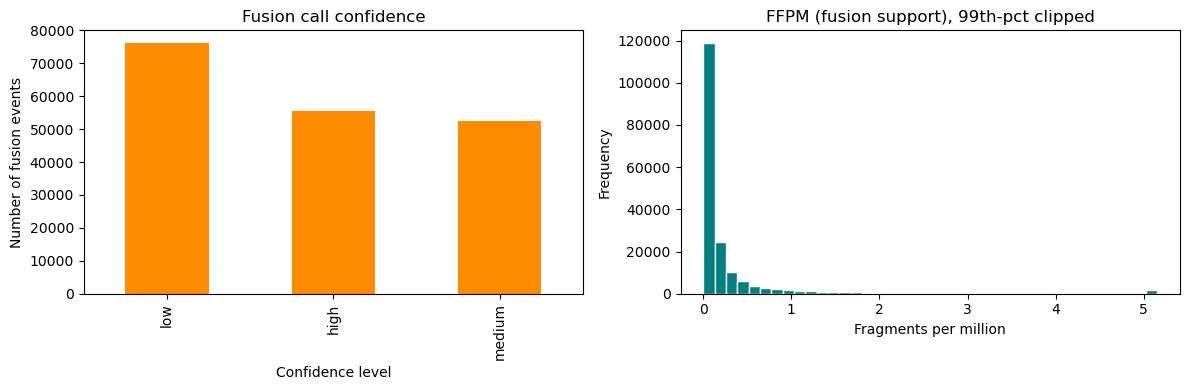

FFPM skewness: 7.96, kurtosis: 91.42


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fusions['confidence'].value_counts().plot(kind='bar', ax=axes[0], color='darkorange')
axes[0].set_title('Fusion call confidence')
axes[0].set_xlabel('Confidence level')
axes[0].set_ylabel('Number of fusion events')

fusions['FFPM'].clip(upper=fusions['FFPM'].quantile(0.99)).plot(
    kind='hist', bins=40, ax=axes[1], color='teal', edgecolor='white'
)
axes[1].set_title('FFPM (fusion support), 99th-pct clipped')
axes[1].set_xlabel('Fragments per million')

plt.tight_layout()
plt.show()

print(f"FFPM skewness: {fusions['FFPM'].skew():.2f}, kurtosis: {fusions['FFPM'].kurt():.2f}")

**Reading the output:** `FFPM` is heavily right-skewed (most fusion calls have low read support, a few have very high support) — a classic candidate for a log transform if used as a numeric feature.

## 2.2 File 6 — Somatic Mutations: missingness across annotation columns

This file has ~70 columns and millions of rows. We use a representative sample (first 200k rows) purely to assess **missingness patterns** — column-level missing *fractions* are stable across the file since annotation availability depends on the variant type/database coverage, not on row position.

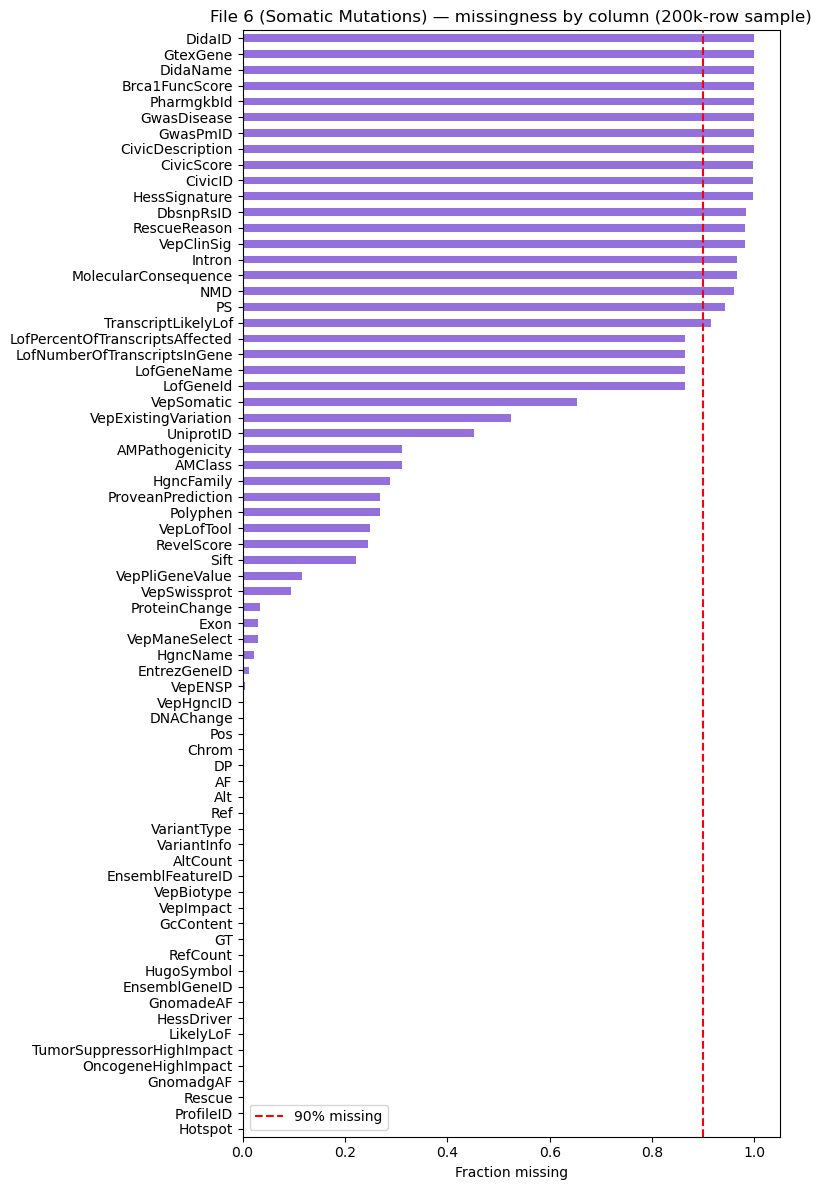

In [8]:
mutations = pd.read_csv(f'{GENE_PROP}/6_OmicsSomaticMutationsProfile.csv', nrows=200_000, low_memory=False)
mut_missing = mutations.isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 12))
mut_missing.plot(kind='barh', ax=ax, color='mediumpurple')
ax.set_xlabel('Fraction missing')
ax.set_title('File 6 (Somatic Mutations) — missingness by column (200k-row sample)')
ax.invert_yaxis()
ax.axvline(0.9, color='red', linestyle='--', label='90% missing')
ax.legend()
plt.tight_layout()
plt.show()

### Reading this chart — column decisions for the mutation table

**Flag to drop (>96% missing — too sparse to be useful even as a binary flag):**
- `DidaID`, `DidaName`, `GtexGene`, `Brca1FuncScore`, `PharmgkbId`, `GwasDisease`, `GwasPmID`, `CivicDescription`, `CivicScore`, `CivicID`, `HessSignature`, `DbsnpRsID`, `RescueReason` — each is a link-out to a specialised clinical database that only covers a tiny fraction of variants. Useful for deep-dives on a *specific* gene, but not as a general modelling feature.

**Flag for imputation / binary-flag conversion (moderately missing, biologically meaningful):**
- `VepClinSig` (~98%), `MolecularConsequence` (~97%), `NMD` (~96%), `Intron` (~97%) — rather than imputing a value, these are best converted to **"is annotation present" binary flags** when aggregating per cell line (e.g. "does this cell line carry >=1 mutation with a known clinical significance flag?").
- `LofGeneName`, `LofGeneId`, `LofNumberOfTranscriptsInGene`, `LofPercentOfTranscriptsAffected` (~86% missing together) — these only populate for loss-of-function variants. Missing = "not a LoF variant", so this is **informative missingness**: encode as 0 / "not LoF" rather than dropping.
- `VepSomatic` (~65%) and `VepExistingVariation` (~52%) — borderline; worth keeping as categorical with an explicit "Unknown" level.

**Keep as-is (low/no missing):** the core variant identity (`Chrom`, `Pos`, `Ref`, `Alt`, `HugoSymbol`, `ProteinChange`, `VariantType`), the driver-gene flags (`OncogeneHighImpact`, `TumorSuppressorHighImpact`, `Hotspot`), and `VepImpact` — these are the columns most directly useful for the "why this cell line" justification and should anchor the per-cell-line aggregation.

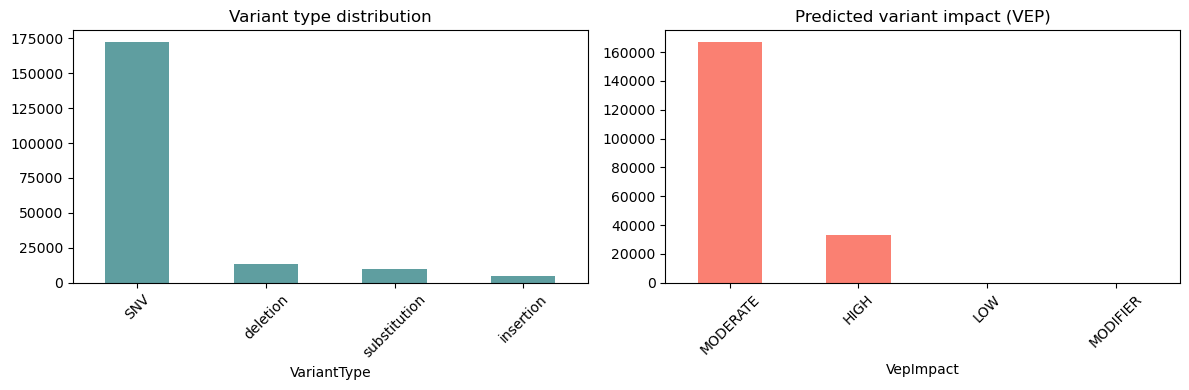

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mutations['VariantType'].value_counts().plot(kind='bar', ax=axes[0], color='cadetblue')
axes[0].set_title('Variant type distribution')
axes[0].tick_params(axis='x', rotation=45)

mutations['VepImpact'].value_counts(dropna=False).plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Predicted variant impact (VEP)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
# 3. Gene Expression — File 2 (DepMap TPM) and File 4 (MS Proteomics)

**Recap:** File 2 is ~1,495 cell lines x ~54,000 gene columns (log2(TPM+1)); File 4 is ~375 cell lines x ~12,558 protein columns. Both are **wide** tables where columns are genes/proteins — far too many to visualise individually.

**Our approach for wide tables:**
- *Missingness* — proteomics (MS) has real missingness ("not detected"); RNA-seq TPM tables generally don't (every gene gets a number, even if it's ~0). We check both.
- *Correlation* — restrict to the **top-N highest-variance genes/proteins**. High-variance genes are the ones that actually *differ* between cell lines, which is exactly the signal a CellLineSelector model needs — low-variance ("housekeeping") genes look the same everywhere and can't help distinguish cell lines.
- *Skewness & kurtosis* — instead of one row per gene, we plot the **distribution of skew/kurtosis values across all genes** as a histogram. This answers "are most genes' expression values roughly symmetric, or is heavy skew the norm?" in one chart.

## 3.1 File 2 — DepMap Expression (RNA, log2(TPM+1))

We load the full table once here — at ~1,495 x 54,000 floats it's large but fits in memory (~600MB), and we need full columns to compute per-gene variance across all cell lines.

In [10]:
depmap_expr = pd.read_csv(f'{GENE_EXPR}/2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv')
depmap_expr = depmap_expr.set_index(depmap_expr.columns[0])
depmap_expr.shape

(1495, 53961)

In [11]:
# Missingness check — is RNA-seq TPM data complete?
total_missing = depmap_expr.isna().sum().sum()
print(f"Total missing values: {total_missing:,} out of {depmap_expr.size:,} ({total_missing/depmap_expr.size:.4%})")

Total missing values: 0 out of 80,671,695 (0.0000%)


**Reading the output:** As expected, RNA-seq expression is essentially complete — every gene gets a measured value for every cell line (even if that value is close to 0 for an unexpressed gene). No missing-data handling needed for this table.

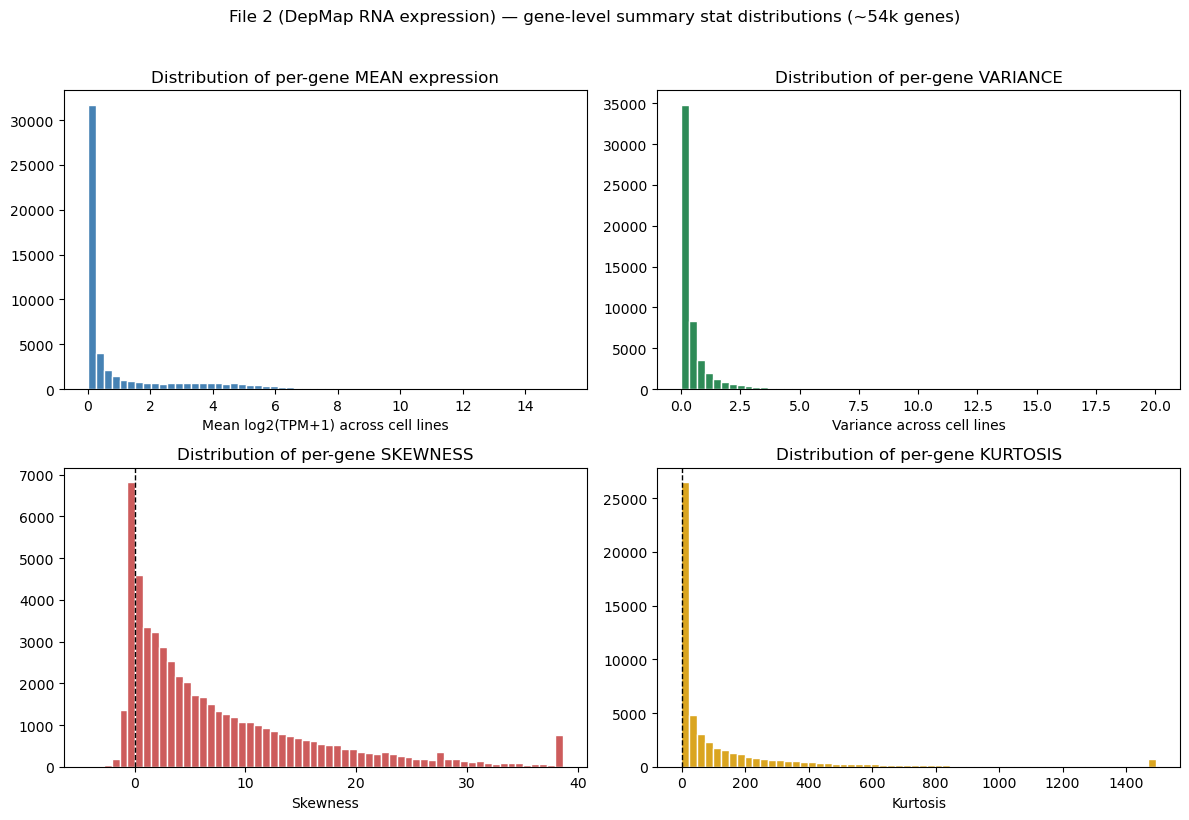

In [12]:
# Per-gene summary statistics across all ~1,495 cell lines
gene_mean = depmap_expr.mean()
gene_var = depmap_expr.var()
gene_skew = depmap_expr.skew()
gene_kurt = depmap_expr.kurt()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(gene_mean, bins=60, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribution of per-gene MEAN expression')
axes[0, 0].set_xlabel('Mean log2(TPM+1) across cell lines')

axes[0, 1].hist(gene_var, bins=60, color='seagreen', edgecolor='white')
axes[0, 1].set_title('Distribution of per-gene VARIANCE')
axes[0, 1].set_xlabel('Variance across cell lines')

axes[1, 0].hist(gene_skew, bins=60, color='indianred', edgecolor='white')
axes[1, 0].set_title('Distribution of per-gene SKEWNESS')
axes[1, 0].set_xlabel('Skewness')
axes[1, 0].axvline(0, color='black', linestyle='--', linewidth=1)

axes[1, 1].hist(gene_kurt, bins=60, color='goldenrod', edgecolor='white')
axes[1, 1].set_title('Distribution of per-gene KURTOSIS')
axes[1, 1].set_xlabel('Kurtosis')
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1)

fig.suptitle('File 2 (DepMap RNA expression) — gene-level summary stat distributions (~54k genes)', y=1.02)
plt.tight_layout()
plt.show()

**Reading the output:**
- **Mean expression** is concentrated near the low end — most genes are expressed at low-to-moderate levels in most cell lines, with a long tail of highly-expressed genes (housekeeping/structural genes).
- **Variance** is also concentrated near 0 — the majority of genes look similar across all cell lines (these are *not* useful for telling cell lines apart). The right tail — high-variance genes — are exactly the candidates for feature selection.
- **Skewness** is overwhelmingly positive (right-skewed) — typical for expression data, since TPM is bounded at 0 and a gene can be "off" in many lines but "highly on" in a few. This supports the log-transform already applied in this file.
- **Kurtosis** is mostly positive and often large — many genes have a few extreme high-expression outlier cell lines sitting on top of a tight low-expression cluster ("heavy tails"). This is useful to know for outlier-robust scaling later.

## 3.2 Correlation heatmap — top 30 highest-variance genes

With ~54,000 genes, a full correlation matrix is unreadable (and computationally wasteful). Instead we take the **30 genes with the highest variance across cell lines** — these are the genes most likely to drive differences between cell lines, and therefore most relevant to a selection model. A correlated cluster among these genes may indicate a shared biological pathway/program.

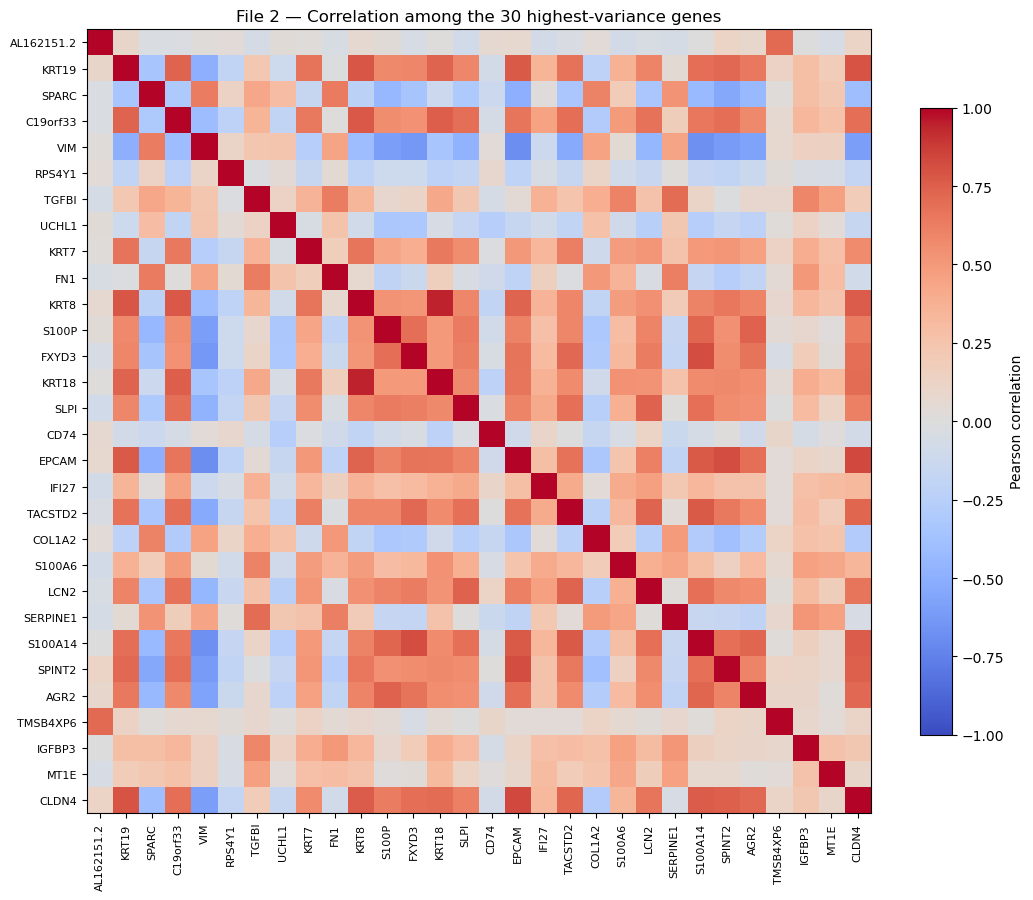

In [13]:
top_var_genes = gene_var.sort_values(ascending=False).head(30).index
corr = depmap_expr[top_var_genes].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(top_var_genes)))
ax.set_yticks(range(len(top_var_genes)))
ax.set_xticklabels([g.split(' ')[0] for g in top_var_genes], rotation=90, fontsize=8)
ax.set_yticklabels([g.split(' ')[0] for g in top_var_genes], fontsize=8)
ax.set_title('File 2 — Correlation among the 30 highest-variance genes')
fig.colorbar(im, ax=ax, label='Pearson correlation', shrink=0.8)
plt.tight_layout()
plt.show()

**Reading the output:** Look for off-diagonal blocks of strong red (positive) or blue (negative) correlation — these indicate groups of genes whose expression rises and falls together across cell lines, often because they're co-regulated (e.g. part of the same signalling pathway, or markers of the same tissue type). Isolated genes with weak correlation to everything else are providing more *independent* information.

## 3.3 File 4 — MS Proteomics (CCLE/Gygi): missingness

Unlike RNA-seq, mass-spec proteomics has genuine "not detected" gaps. We look at the **distribution of missingness across proteins** (columns) — this tells us how many proteins are reliably measured vs. how many are only sporadically detected.

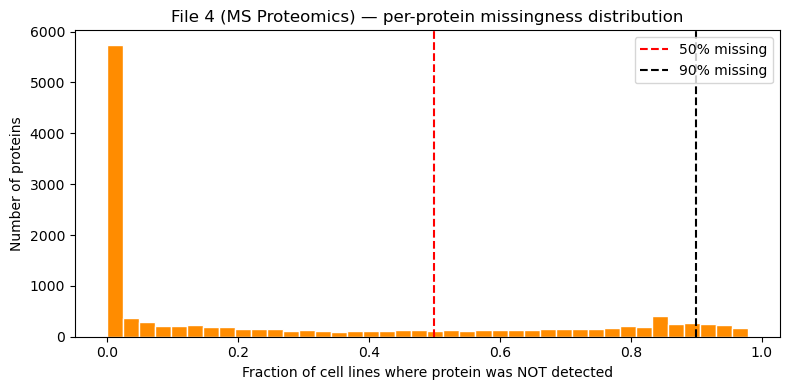

Proteins with >50% missing: 3,544 / 12,558
Proteins with >90% missing: 834 / 12,558


In [14]:
ms_ccle = pd.read_csv(f'{GENE_EXPR}/4_Harmonized_MS_CCLE_Gygi_subsetted.csv')
ms_ccle = ms_ccle.set_index(ms_ccle.columns[0])

col_missing = ms_ccle.isna().mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(col_missing, bins=40, color='darkorange', edgecolor='white')
ax.set_xlabel('Fraction of cell lines where protein was NOT detected')
ax.set_ylabel('Number of proteins')
ax.set_title('File 4 (MS Proteomics) — per-protein missingness distribution')
ax.axvline(0.5, color='red', linestyle='--', label='50% missing')
ax.axvline(0.9, color='black', linestyle='--', label='90% missing')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Proteins with >50% missing: {(col_missing > 0.5).sum():,} / {len(col_missing):,}")
print(f"Proteins with >90% missing: {(col_missing > 0.9).sum():,} / {len(col_missing):,}")

### Reading this chart — column decisions for File 4

- **Flag to drop (>90% missing, ~834 proteins / 6.6%):** these proteins are essentially never detected across the panel — too sparse to model, and almost certainly low-abundance proteins near the mass-spec detection limit.
- **Flag for imputation (between ~10-50% missing, ~2,700 proteins):** these proteins *are* detected in most cell lines, with sporadic gaps. Because `NaN` here means "below detection", a reasonable imputation strategy is a **small constant floor value** (e.g. the dataset's minimum observed abundance) rather than the column mean — imputing with the mean would overstate how much protein is actually present.
- **Keep as-is (<10% missing, the majority):** safe to use directly.

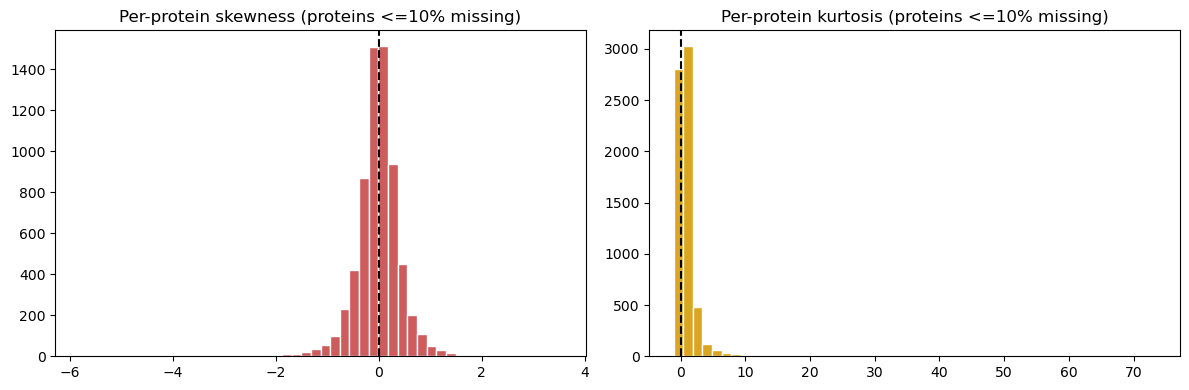

In [15]:
# Skewness/kurtosis distribution across proteins (using only reasonably-complete columns)
well_measured = ms_ccle.loc[:, col_missing <= 0.1]
prot_skew = well_measured.skew()
prot_kurt = well_measured.kurt()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(prot_skew, bins=50, color='indianred', edgecolor='white')
axes[0].set_title('Per-protein skewness (proteins <=10% missing)')
axes[0].axvline(0, color='black', linestyle='--')

axes[1].hist(prot_kurt, bins=50, color='goldenrod', edgecolor='white')
axes[1].set_title('Per-protein kurtosis (proteins <=10% missing)')
axes[1].axvline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

**Reading the output:** Compared to RNA expression (File 2), protein abundances here are already roughly centred (these values are relative/standardised abundances, hence negatives are possible), so skewness clusters closer to 0 — most proteins follow a roughly symmetric distribution across cell lines, with a moderate right tail. This is a much milder departure from normality than raw RNA TPM.

---
# 4. Non-Gene-Expression — Files 12, 13, 14

These files are much narrower (12 to ~950 columns), so full or near-full correlation heatmaps are feasible.

## 4.1 File 14 — Global Genome Signatures (full correlation)

Only 6 numeric biological columns (`MSIScore`, `LoHFraction`, `WGD`, `CIN`, `Ploidy`, `Aneuploidy`) — small enough for a complete correlation matrix and per-column skew/kurtosis table.

In [16]:
global_sig = pd.read_csv(f'{NON_GENE_EXPR}/14_OmicsGlobalSignatures.csv')
numeric_cols = ['MSIScore', 'LoHFraction', 'WGD', 'CIN', 'Ploidy', 'Aneuploidy']

print("Missing fraction:")
print(global_sig[numeric_cols].isna().mean())

Missing fraction:
MSIScore       0.000000
LoHFraction    0.145316
WGD            0.145316
CIN            0.145316
Ploidy         0.145316
Aneuploidy     0.145316
dtype: float64


**Reading the output:** Five of the six scores share the same ~14.5% missingness, but **`MSIScore` is fully populated (0% missing)** and must be treated separately — almost certainly because they come from a single downstream analysis step that simply wasn't run for that subset of profiles (whole-genome sequencing may not be available for every cell line, recall File 8 showed only ~475 `wgs` profiles vs ~1,860 `wes`). 

**Decision:** flag for imputation as a group — these are too biologically informative (MSI-high status is a real clinical biomarker) to drop, but the five WGS-derived scores (`LoHFraction`, `WGD`, `CIN`, `Ploidy`, `Aneuploidy`) should be imputed together (e.g. median per cancer lineage), while `MSIScore` needs no special handling or modelled with an explicit "data available: yes/no" flag, since the missingness itself is informative (tied to sequencing type, not random).

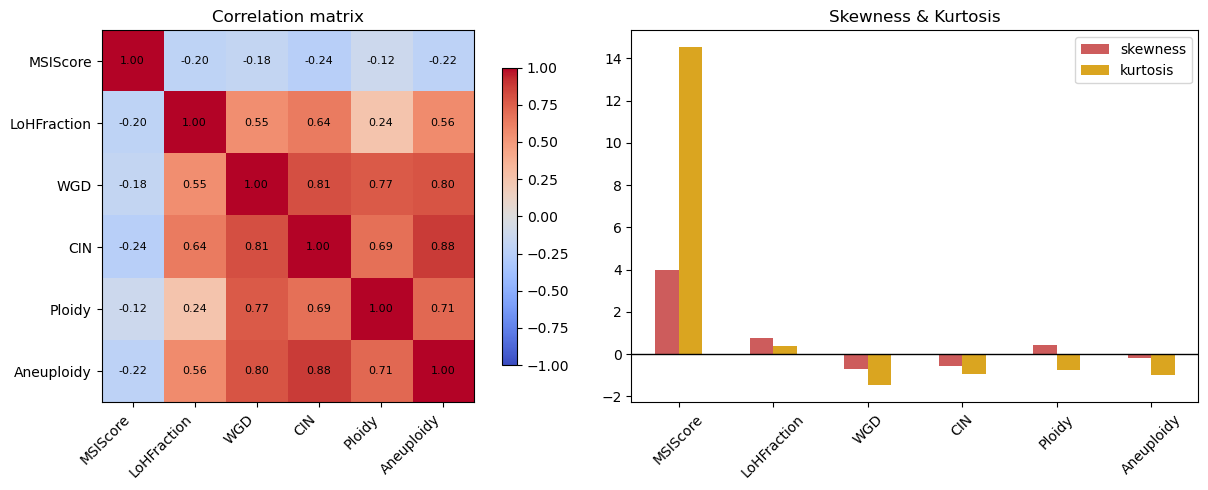

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

corr14 = global_sig[numeric_cols].corr()
im = axes[0].imshow(corr14, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(numeric_cols)))
axes[0].set_yticks(range(len(numeric_cols)))
axes[0].set_xticklabels(numeric_cols, rotation=45, ha='right')
axes[0].set_yticklabels(numeric_cols)
axes[0].set_title('Correlation matrix')
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        axes[0].text(j, i, f'{corr14.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=axes[0], shrink=0.8)

skew_kurt = pd.DataFrame({
    'skewness': global_sig[numeric_cols].skew(),
    'kurtosis': global_sig[numeric_cols].kurt(),
})
skew_kurt.plot(kind='bar', ax=axes[1], color=['indianred', 'goldenrod'])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Skewness & Kurtosis')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Reading the output:** `CIN` (chromosomal instability) and `Aneuploidy` are strongly positively correlated — unsurprising, as both measure related aspects of genome disorganisation; this is worth knowing if both end up as model features (risk of redundancy/multicollinearity). `Ploidy` shows the highest kurtosis — most cell lines cluster tightly around the normal diploid/near-diploid range, with a few extreme outliers (highly polyploid tumours).

## 4.2 File 12 — CCLE Metabolomics (~225 metabolites)

225 numeric columns is still too many for a single readable heatmap with labels, but manageable if we focus on the **top 30 highest-variance metabolites** — the ones that vary most across cell lines and are therefore most useful for distinguishing between them.

In [18]:
metabolomics = pd.read_csv(f'{NON_GENE_EXPR}/12_CCLE_metabolomics_20190502.csv')
metab_cols = metabolomics.columns[2:]
print(f"Missing fraction (overall): {metabolomics[metab_cols].isna().mean().mean():.4%}")
print(f"Rows with missing DepMap_ID: {metabolomics['DepMap_ID'].isna().sum()} / {len(metabolomics)}")

Missing fraction (overall): 0.0000%
Rows with missing DepMap_ID: 1 / 928


**Reading the output:** Metabolite measurements themselves are essentially complete. The one thing to flag: a tiny number of rows (~0.1%) are missing `DepMap_ID` — these rows can't be joined to the rest of our data via the standard key, so they should either be matched manually via `CCLE_ID` or dropped from the modelling set.

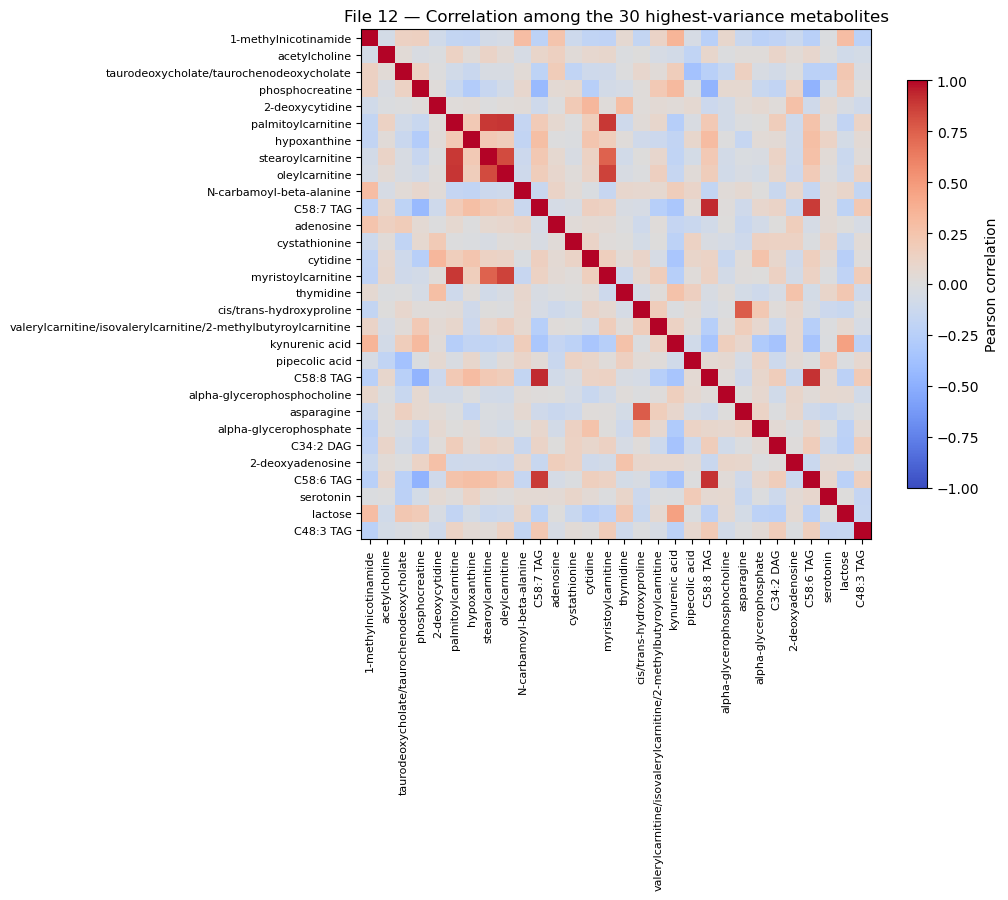

In [19]:
metab_var = metabolomics[metab_cols].var().sort_values(ascending=False)
top_var_metab = metab_var.head(30).index

fig, ax = plt.subplots(figsize=(11, 9))
corr12 = metabolomics[top_var_metab].corr()
im = ax.imshow(corr12, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(top_var_metab)))
ax.set_yticks(range(len(top_var_metab)))
ax.set_xticklabels(top_var_metab, rotation=90, fontsize=8)
ax.set_yticklabels(top_var_metab, fontsize=8)
ax.set_title('File 12 — Correlation among the 30 highest-variance metabolites')
fig.colorbar(im, ax=ax, label='Pearson correlation', shrink=0.8)
plt.tight_layout()
plt.show()

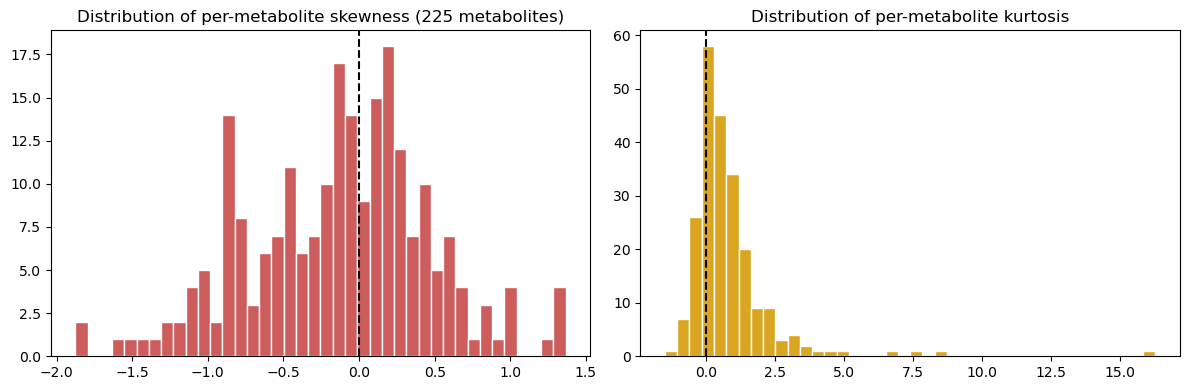

In [20]:
metab_skew = metabolomics[metab_cols].skew()
metab_kurt = metabolomics[metab_cols].kurt()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(metab_skew, bins=40, color='indianred', edgecolor='white')
axes[0].set_title('Distribution of per-metabolite skewness (225 metabolites)')
axes[0].axvline(0, color='black', linestyle='--')

axes[1].hist(metab_kurt, bins=40, color='goldenrod', edgecolor='white')
axes[1].set_title('Distribution of per-metabolite kurtosis')
axes[1].axvline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

**Reading the output:** Like RNA expression, most metabolites are right-skewed with heavy tails (high positive kurtosis) — a handful of cell lines have unusually high levels of certain metabolites (likely reflecting distinct metabolic states, e.g. highly glycolytic vs. oxidative tumours). A log transform would be reasonable before using these as model features.

## 4.3 File 13 — CCLE miRNA (~734 miRNAs x ~954 cell lines)

Recall this table is **transposed** — miRNAs are rows, cell lines are columns. We transpose it here so cell lines become rows again (consistent with everything else), then apply the same top-variance approach.

In [21]:
mirna_raw = pd.read_csv(f'{NON_GENE_EXPR}/13_CCLE_miRNA_20181103.gct', sep='\t', skiprows=2)
mirna = mirna_raw.drop(columns=['Description']).set_index('Name').T  # cell lines as rows, miRNAs as columns
mirna.shape

(954, 734)

Missing fraction (overall): 0.0000%


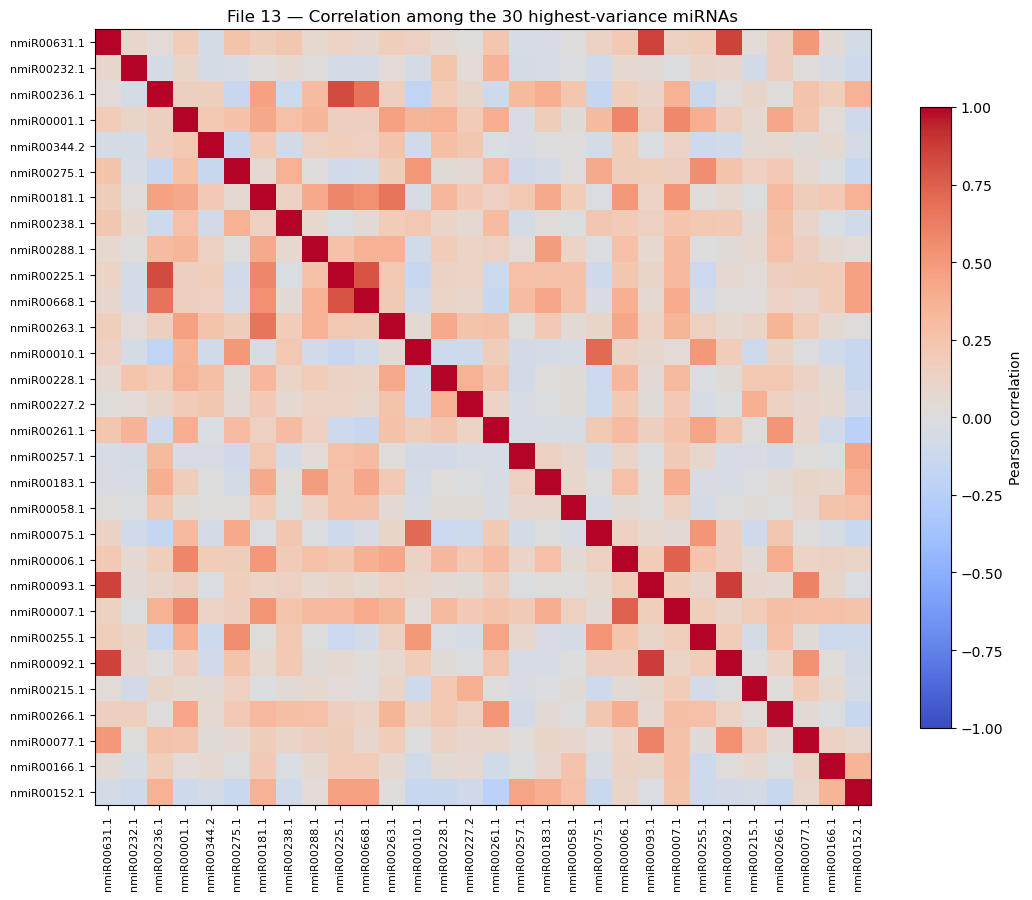

In [22]:
print(f"Missing fraction (overall): {mirna.isna().mean().mean():.4%}")

mirna_var = mirna.var(numeric_only=True).sort_values(ascending=False)
top_var_mirna = mirna_var.head(30).index

fig, ax = plt.subplots(figsize=(11, 9))
corr13 = mirna[top_var_mirna].corr()
im = ax.imshow(corr13, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(top_var_mirna)))
ax.set_yticks(range(len(top_var_mirna)))
ax.set_xticklabels(top_var_mirna, rotation=90, fontsize=8)
ax.set_yticklabels(top_var_mirna, fontsize=8)
ax.set_title('File 13 — Correlation among the 30 highest-variance miRNAs')
fig.colorbar(im, ax=ax, label='Pearson correlation', shrink=0.8)
plt.tight_layout()
plt.show()

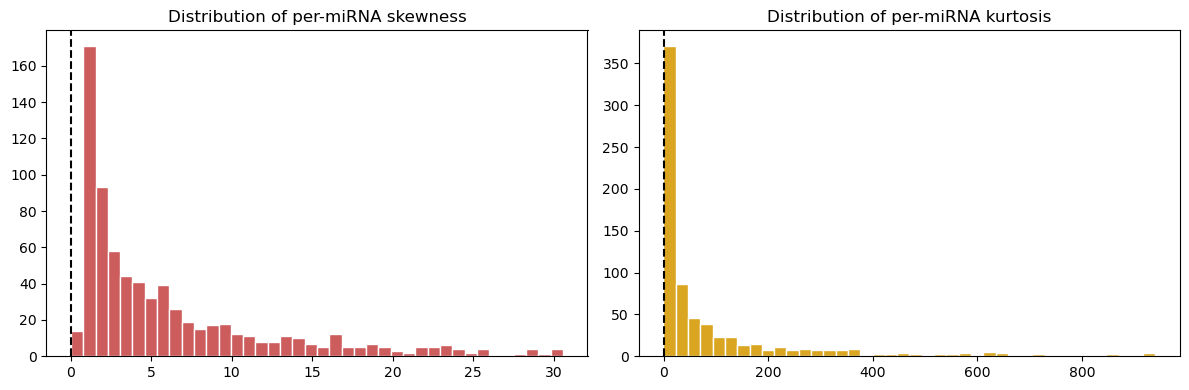

In [23]:
mirna_skew = mirna.skew(numeric_only=True)
mirna_kurt = mirna.kurt(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(mirna_skew, bins=40, color='indianred', edgecolor='white')
axes[0].set_title('Distribution of per-miRNA skewness')
axes[0].axvline(0, color='black', linestyle='--')

axes[1].hist(mirna_kurt, bins=40, color='goldenrod', edgecolor='white')
axes[1].set_title('Distribution of per-miRNA kurtosis')
axes[1].axvline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

**Reading the output:** miRNA expression shows the same right-skewed, heavy-tailed pattern we've now seen repeatedly across RNA, protein, and metabolite layers — this is a general property of biological abundance data (values are non-negative and span orders of magnitude), and reinforces that **log-transformation should be a standard step** in the preprocessing pipeline for all continuous omics layers.

---
# 5. Summary — column-flagging cheat sheet for preprocessing

| File | Drop (too sparse) | Impute / flag (sparse but useful) | Notes |
|---|---|---|---|
| 9 (Sample Info) | `model_manipulation*`, `depmap_public_comments`, `parent_depmap_id`, `alias`, `lineage_molecular_subtype`, `Cellosaurus_issues` | `lineage_sub_subtype`, `primary_or_metastasis`, `age`, `Subtype`, cross-ref IDs (`COSMICID`, `Sanger_Model_ID`, `WTSI_Master_Cell_ID`) | Core ID/lineage/disease columns are complete |
| 5 (Fusions) | — | — | Fully populated; `FFPM` is right-skewed -> consider log |
| 6 (Mutations) | `DidaID/Name`, `GtexGene`, `Brca1FuncScore`, `PharmgkbId`, `Gwas*`, `Civic*`, `HessSignature`, `DbsnpRsID`, `RescueReason` | `VepClinSig`, `MolecularConsequence`, `NMD`, `Intron`, `Lof*` (-> binary flags), `VepSomatic`, `VepExistingVariation` | Driver-gene flags & `VepImpact` are complete and high-value |
| 2 (DepMap RNA) | — | — | Effectively no missing values; heavy right-skew is expected (already log-scaled) |
| 4 (MS Proteomics) | ~834 proteins >90% missing | ~2,700 proteins 10-50% missing -> impute with detection-floor value, not mean | |
| 12 (Metabolomics) | rows with missing `DepMap_ID` (~0.1%) | — | Right-skewed -> consider log |
| 13 (miRNA) | — | — | Right-skewed -> consider log; remember to transpose |
| 14 (Global Signatures) | — | 5 WGS-derived scores (LoH/WGD/CIN/Ploidy/Aneuploidy) ~14.5% missing (tied to WGS); MSIScore is complete (0% missing) | `CIN` & `Aneuploidy` strongly correlated -> watch for redundancy |

## Cross-cutting takeaway

Every continuous omics layer we examined (RNA, protein, metabolite, miRNA) shows the **same right-skewed, heavy-tailed shape** — a handful of cell lines are extreme outliers for any given feature, while most cluster at lower values. This is normal for biological abundance data, but it means the preprocessing pipeline (`preprocessing/`) should apply a **consistent log/standardisation step** across all continuous omics features before they reach any model, rather than treating each data source differently.

## In Plain English — What This Notebook Means & Where It Goes Next

### 1. What this notebook actually is (layman terms)
The earlier notebooks asked *"what is this data?"* **This one asks the next question: "is the data actually usable, and how do we clean it before a model sees it?"** It's a **data-quality pass**. For the most important datasets it looks at three things over and over: **how much is missing**, **what shape the numbers have** (are they lopsided?), and **which features actually differ between cell lines** (vs. ones that look the same everywhere and tell us nothing).

A key practical idea here: these tables are enormous (e.g., 54,000 genes), so instead of staring at every column, the notebook **summarises the columns** — e.g., "how spread out is each gene across cell lines?" — and plots *those summaries*. That's how you sanity-check 54,000 genes on one chart.

### 2. What we found, and the next steps (preprocessing decisions)
What the notebook showed:
- **The metadata "patient chart" (file 9) has gaps**: ~10 columns are almost entirely empty (drop them), a few are partly empty but meaningful like age/subtype (fill them in sensibly), and the core fields are nearly complete (keep).
- **Every continuous biology layer — genes, proteins, metabolites, miRNA — has the same lopsided shape** (i.e., "right-skewed": most cell lines show a little of something, a few show a huge amount). This is *normal* for biological abundance data and it means **one consistent fix applies everywhere: log-transform** (a standard squashing step that tames the lopsidedness).
- **Most features are boring** (they barely change between cell lines, like always-on housekeeping genes) and **only the high-variance features carry the signal** that distinguishes one cell line from another. The correlation heatmaps show those informative features travel in **co-regulated groups** (i.e., genes in the same biological pathway rise and fall together) — useful for explaining *why* a line was chosen.
- **Missingness means different things in different layers**, so it can't be handled the same way: RNA has none; **proteomics blanks mean "not detected"** → fill with a low/floor value (not the average, which would lie); **genome scores are missing in a block** for lines that weren't whole-genome sequenced → flag rather than guess.
- **Heavy "tails" (extreme outliers) are everywhere** → favour outlier-resistant scaling.

Next steps (the preprocessing pipeline this notebook prescribes):
- **Apply log-transform consistently** to all continuous omics layers.
- **Variance-filter**: drop the near-constant features, keep the informative high-variance ones.
- **Impute by rule, per layer**: detection-floor for proteins, "Unknown"/median (ideally per cancer type) for metadata, flags for the WGS-only genome scores; convert sparse-but-meaningful mutation annotations into **yes/no flags** rather than dropping them.
- **Use robust/outlier-resistant scaling** given the heavy tails.

Still missing: this is a *diagnosis* notebook — it decides *what* to do; the actual cleaning belongs in the reusable preprocessing scripts (`pipeline_v0`).

### 3. Which ML approach fits
The patterns here favour **tree-based supervised models (random forest / gradient boosting) plus up-front feature selection**, because:
- They **handle heavy tails and outliers gracefully** and don't demand perfectly normal data.
- They cope with **thousands of features** if we variance-filter first.
- They're **interpretable** — feature-importance tells researchers *which* genes/mutations drove a pick, which is exactly the "why this cell line" the project demands.

A sensible **two-stage** design also falls out of the findings: first use the information-rich omics to fill in or sanity-check the patchy metadata (e.g., infer tissue from expression), then feed the cleaned metadata + selected omics features into the final selection/ranking model. **Unsupervised** methods (PCA, clustering) remain useful alongside, both as a sanity check that cell lines group by tissue and to power "similar cell line" suggestions.

> **Big-picture note:** This notebook is the bridge from "we understand the data" to "here's the cleaning recipe." Its headline rule — *log-transform + variance-filter every continuous omics layer, impute missingness by its biological cause* — is what makes the combined dataset safe to train on.